In [1]:
import pandas as pd
import cv2
import os
import numpy as np

os.makedirs("../output/", exist_ok=True)
os.makedirs("../output/metrics", exist_ok=True)
os.makedirs("../output/models", exist_ok=True)
os.makedirs("../output/plots", exist_ok=True)
os.makedirs("../output/importance", exist_ok=True)
os.makedirs("../output/pdp", exist_ok=True)

In [2]:
feature_names = ["Temp_Annual_Mean","Temp_Annual_Seasonality","Pre_Annual_Mean","Pre_Annual_Seasonality","Pre_Annual_DriestQuarter"]
n_fold = 5

In [3]:
from tqdm.auto import tqdm
import numpy as np
import pickle
species_label_names = [x.split(".csv")[0] for x in list(sorted(os.listdir("../data_new/labels")))]

feature_data = pd.read_csv("../data_new/combined.csv")[feature_names]

from sklearn.impute import SimpleImputer

impute = SimpleImputer(strategy="mean")
impute.fit(feature_data[feature_names].values)
with open("../output/imputer.pkl", "wb") as file:
    pickle.dump(impute, file)

/home/xlluo/anaconda3/envs/zhongkeyuan/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from sklearn.model_selection import StratifiedKFold
from imblearn.under_sampling import RandomUnderSampler
import numpy as np
from sklearn.utils import indexable

class BalancedStratifiedKFold(StratifiedKFold):
    def split(self, X, y=None, groups=None):
        X, y, groups = indexable(X, y, groups)
        for train, test in super().split(X, y, groups):
            train_label = y[train]
            sampler = RandomUnderSampler(random_state=1)
            resample_train, _ = sampler.fit_resample(np.reshape(train, (-1, 1)), train_label)
            yield resample_train.flatten(), test

In [5]:
from sklearn.metrics import confusion_matrix, make_scorer
from utils import tss

tss_score = make_scorer(tss)

grid = {
    'max_depth': [5, 10, 15, 20],
    'n_estimators': [40, 80, 120, 160],
}

scorers = {"roc_auc": "roc_auc", "tss": tss_score}

from sklearn.model_selection import GridSearchCV, cross_validate
from sklearn.ensemble import RandomForestClassifier
import pickle
from tqdm.auto import tqdm

for species_idx, species_name in enumerate(tqdm(species_label_names)):
    species_label_all = pd.read_csv(f"../data_new/labels/{species_name}.csv")[species_name]
    species_data = feature_data[pd.notna(species_label_all)].dropna(axis=0)
    species_label = species_label_all[species_data.index].values.flatten()
    species_data.reset_index(drop=True)
    if len(np.unique(species_label)) > 2:
        print(species_name, "has more than two labels:", np.unique(species_label))
        continue
    if not all([x in [0, 1] for x in np.unique(species_label)]):
        print(species_name, "has unexpected labels:", np.unique(species_label))
        continue
    if len(np.where(species_label==1)[0])<=10:
        continue
    if not len(np.where(species_label==0)[0])>=1:
        continue
    
    rf = RandomForestClassifier(random_state=0, n_jobs=-1)
    inner_cv = StratifiedKFold(n_splits=n_fold, shuffle=True, random_state=0)
    outer_cv = BalancedStratifiedKFold(n_splits=n_fold, shuffle=True, random_state=0)
    try:
        clf = GridSearchCV(estimator=rf, param_grid=grid, cv=inner_cv, scoring=scorers, refit="roc_auc")
        res = cross_validate(estimator=clf, X=species_data, y=species_label, cv=outer_cv, scoring=scorers, return_estimator=True, return_train_score=True, n_jobs=-1)
        best_params = [i_est.best_params_ for i_est in res["estimator"]]
    except:
        continue
    
    val_mean_auc = [i_est.cv_results_["mean_test_roc_auc"][i_est.best_index_] for i_est in res["estimator"]]
    val_std_auc = [i_est.cv_results_["std_test_roc_auc"][i_est.best_index_] for i_est in res["estimator"]]
    val_mean_tss = [i_est.cv_results_["mean_test_tss"][i_est.best_index_] for i_est in res["estimator"]]
    val_std_tss = [i_est.cv_results_["std_test_tss"][i_est.best_index_] for i_est in res["estimator"]]
    test_auc = res["test_roc_auc"]
    test_tss = res["test_tss"]
    df_metric = pd.DataFrame({col: data for col, data in zip(["Fold", "Validation AUC mean", "Validation AUC std", "Validation TSS mean", "Validation TSS std", "Testing AUC", "Testing TSS", "Best parameters"], [list(range(1, n_fold+1)), val_mean_auc, val_std_auc, val_mean_tss, val_std_tss, test_auc, test_tss, best_params])})
    df_metric.to_csv(f"../output/metrics/{species_name}_auc_tss_{n_fold}fold.csv", index=False)
    with open(f"../output/models/{species_name}_models.pkl", "wb") as file:
        pickle.dump(res["estimator"], file)

  0%|          | 0/3103 [00:00<?, ?it/s]

  1%|          | 34/3103 [14:44<16:28:22, 19.32s/it]/home/xlluo/anaconda3/envs/zhongkeyuan/lib/python3.9/site-packages/sklearn/model_selection/_split.py:700: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
 30%|██▉       | 916/3103 [7:11:47<6:22:42, 10.50s/it] /home/xlluo/anaconda3/envs/zhongkeyuan/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:378: FitFailedWarning: 
1 fits failed out of a total of 5.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "/home/xlluo/anaconda3/envs/zhongkeyuan/lib/python3.9/site-packages/sklearn/model_selection/_validation.py", line 686, in _fit_

In [6]:
import os
from sklearn.inspection import partial_dependence
import shap
import pickle
from imblearn.under_sampling import RandomUnderSampler
sampler = RandomUnderSampler(random_state=0)

overall_importance = []

for filename in tqdm(os.listdir("../output/models")):
    species_name = filename.split("_models.pkl")[0]
    species_label_all = pd.read_csv(f"../data_new/labels/{species_name}.csv")[species_name]
    species_data = feature_data[pd.notna(species_label_all)].dropna(axis=0)
    species_label = species_label_all[species_data.index].values.flatten()
    species_data.index = np.arange(len(species_data))
    resample_train, _ = sampler.fit_resample(np.arange(len(species_data)).reshape(-1, 1), species_label)
    species_data = species_data.loc[resample_train.flatten(), :]
    
    with open(f"../output/models/{filename}", "rb") as file:
        models = pickle.load(file)
    importances = []
    feature_values = {feature: [] for feature in feature_names}
    pdp_values = {feature: [] for feature in feature_names}
    for model in models:
        model.best_estimator_.set_params(n_jobs=-1)
        # explainer = shap.TreeExplainer(model.best_estimator_, seed=0)
        # shap_values = explainer(species_data)
        # importance = np.mean(
        #             np.abs(shap_values.values[:, :, 0]), axis=0
        #         )
        importance = model.best_estimator_.feature_importances_
        importances.append(importance)
        overall_importance.append(importance)
        for feature in feature_names:
            pdp_result = partial_dependence(model.best_estimator_, species_data,
                                                    [feature], grid_resolution=20,
                                                    kind='average')
            feature_values[feature].append(pdp_result["values"][0])
            pdp_values[feature].append(pdp_result["average"][0])
    df_importance = pd.DataFrame(data=np.array(importances), columns=feature_names)
    df_importance.to_csv(os.path.join("../output/importance/", species_name+"_importance.csv"), index=False)
    for feature in feature_names:
        df_pdp = pd.DataFrame(data=np.array(pdp_values[feature]), columns=feature_values[feature][0])
        df_pdp.to_csv(os.path.join("../output/pdp/", f"{species_name}_{feature}.csv"), index=True)

100%|██████████| 2167/2167 [12:56:05<00:00, 21.49s/it]  


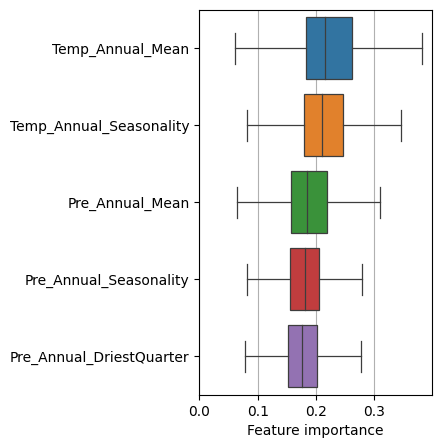

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(3,5), dpi=100)
ax = plt.subplot(111)

sns.boxplot(data=pd.DataFrame(np.array(overall_importance), columns=feature_names), order=list(np.array(feature_names)[np.argsort(np.median(np.array(overall_importance), axis=0))])[::-1], orient='h', linewidth=0.9,
                 showfliers = False, fliersize=4, flierprops={'marker': 'o'}, boxprops={"zorder": 10}, whiskerprops={'zorder': 10}, zorder=10, ax=ax)

ax.set_xlabel("Feature importance")
ax.grid(axis="x")
ax.set_xlim(left=0)
plt.savefig("../output/importance_all.jpg", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

In [8]:
feature_file_map = {"Temp_Annual_Mean": "Temp_Annual_Mean.tif","Temp_Annual_Seasonality": "Temp_Annual_Seasonality.tif","Pre_Annual_Mean": "Pre_Annual_Mean.tif","Pre_Annual_Seasonality": "Pre_Annual_Seasonality.tif","Pre_Annual_DriestQuarter": "Pre_Annual_DriestQuarter.tif"}
import numpy as np
from libtiff import TIFF
feature_img = []
for feature in feature_names:
    img = TIFF.open('../data_new/' + feature_file_map[feature]).read_image()
    img = np.nan_to_num(img, nan=-9999, neginf=-9999, posinf=-9999).astype(float)
    feature_img.append(img)
    # print(img)
nrows = feature_img[0].shape[0]
ncols = feature_img[0].shape[1]
mask = feature_img[0]!=-9999


TIFFReadDirectory: Warning, Unknown field with tag 33550 (0x830e) encountered.
TIFFReadDirectory: Warning, Unknown field with tag 33922 (0x8482) encountered.
TIFFReadDirectory: Warning, Unknown field with tag 34735 (0x87af) encountered.
TIFFReadDirectory: Warning, Unknown field with tag 34736 (0x87b0) encountered.
TIFFReadDirectory: Warning, Unknown field with tag 34737 (0x87b1) encountered.
TIFFReadDirectory: Warning, Unknown field with tag 42112 (0xa480) encountered.
TIFFReadDirectory: Warning, Unknown field with tag 33550 (0x830e) encountered.
TIFFReadDirectory: Warning, Unknown field with tag 33922 (0x8482) encountered.
TIFFReadDirectory: Warning, Unknown field with tag 34735 (0x87af) encountered.
TIFFReadDirectory: Warning, Unknown field with tag 34736 (0x87b0) encountered.
TIFFReadDirectory: Warning, Unknown field with tag 34737 (0x87b1) encountered.
TIFFReadDirectory: Warning, Unknown field with tag 42112 (0xa480) encountered.
TIFFReadDirectory: Warning, Unknown field with tag 3

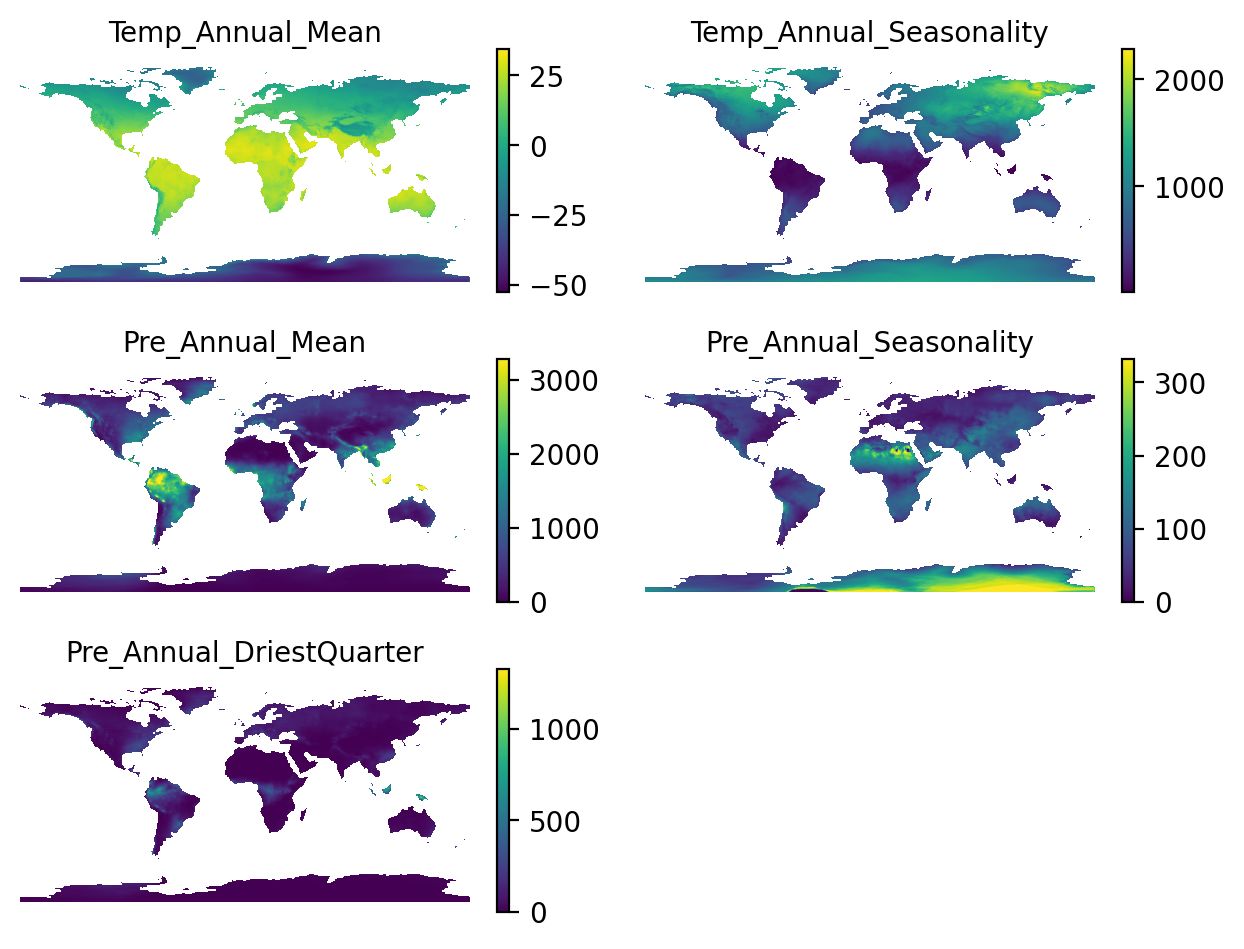

In [9]:
from matplotlib import pyplot as plt
import copy
plt.figure(dpi=200)
for idx in range(len(feature_names)):
    plt.subplot(3,2,idx+1)
    img = copy.deepcopy(feature_img[idx])
    img[img<-5000] = np.nan
    img[mask==0] = np.nan
    im = plt.imshow(img)

    plt.title(feature_names[idx],size=10)
    plt.colorbar()
    plt.axis('off')

plt.tight_layout()
plt.show()
plt.close()

In [10]:
import multiprocessing
from tqdm.auto import tqdm
import pickle
from sklearn.impute import SimpleImputer
import seaborn as sns
import cv2
import copy
import warnings
import matplotlib.pyplot as plt
import zipfile
sns.reset_defaults()

with open("../output/imputer.pkl", "rb") as file:
    impute = pickle.load(file)

def par_func(tmp_model):
    predicted_img_tmp = np.ones_like(img).astype(np.float16) * -9999

    for row in range(nrows):

        feature_map_data = pd.DataFrame()
        for feature_idx, feature in enumerate(feature_names):
            feature_map_data[feature] = feature_img[feature_idx][row, :]
        feature_map_data = feature_map_data.loc[mask[row, :], :].reset_index(drop=True)
        if len(feature_map_data) == 0:
            continue

        data = np.nan_to_num(feature_map_data.values, nan=np.nan, posinf=np.nan, neginf=np.nan)
        data[data>1e12] = np.nan
        data[data<-1e12] = np.nan
        feature_map_data.loc[:, :] = impute.transform(data)
        # print(feature_map_data.describe())
        y = tmp_model.predict_proba(feature_map_data)[:, 1]
        predicted_img_tmp[row, mask[row, :]] = y

    # print('done')
    return predicted_img_tmp

cores = 5
pool = multiprocessing.Pool(processes=cores)
print('Running on ', cores, ' cores.')

for filename in tqdm(os.listdir("../output/models")):
    species_name = filename.split("_models.pkl")[0]
    with open(f"../output/models/{species_name}_models.pkl", "rb") as file:
        estimators = pickle.load(file)
    for estimator in estimators:
        estimator.set_params(n_jobs=1)
        estimator.best_estimator_.set_params(n_jobs=1)

    predicted_img_stack = np.zeros((nrows, ncols, n_fold), dtype='float16')

    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", "Loky-backed", UserWarning)
        for idx, res in enumerate(pool.imap(par_func,estimators)):
            predicted_img_stack[:, :, idx] = res

    predicted_img_avg = np.ones_like(img) * -9999
    predicted_img_std = np.ones_like(img) * -9999

    for row in range(nrows):
        predicted_img_avg[row, mask[row, :]] = np.mean(predicted_img_stack[row, mask[row, :], :], axis=1).astype(np.float32)
        predicted_img_std[row, mask[row, :]] = np.std(predicted_img_stack[row, mask[row, :], :], axis=1).astype(np.float32)

    from matplotlib.gridspec import GridSpec
    img = copy.deepcopy(predicted_img_avg)
    img[mask==0] = np.nan

    fig = plt.figure()
    ax = plt.subplot(111)
    im = ax.imshow(img,cmap='bwr')
    plt.title('Predicted Risk (Mean)')

    gs = GridSpec(100, 100, figure=fig)
    cax = fig.add_subplot(gs[50:68, 9:11])
    cax.yaxis.set_tick_params(width=0.5)
    cbar = plt.colorbar(cax=cax, mappable=im)
    cbar.outline.set_linewidth(0.5)
    cbar.ax.tick_params(axis='y', colors="black")
    [x.set_edgecolor('black') for x in cbar.ax.spines.values()]

    plt.sca(ax=ax)
    plt.box(False)
    plt.xticks([])
    plt.yticks([])
    [x.set_linewidth(0.5) for x in ax.spines.values()]
    [x.set_edgecolor("white") for x in ax.spines.values()]
    # plt.show()
    plt.savefig('../output/plots/predicted_avg_' + species_name + '.png', dpi=500, bbox_inches='tight')
    # plt.show()
    plt.close()

    cv2.imwrite(f'../output/plots/predicted_avg_{species_name}.tif', np.nan_to_num(img, copy=True, nan=-9999))

    img = copy.deepcopy(predicted_img_std)
    img[mask==0] = np.nan

    fig = plt.figure()
    ax = plt.subplot(111)
    im = ax.imshow(img,cmap='bwr')
    plt.title('Predicted Risk (Standard Deviation)')

    gs = GridSpec(100, 100, figure=fig)
    cax = fig.add_subplot(gs[50:68, 9:11])
    cax.yaxis.set_tick_params(width=0.5)
    cbar = plt.colorbar(cax=cax, mappable=im)
    cbar.outline.set_linewidth(0.5)
    cbar.ax.tick_params(axis='y', colors="black")
    [x.set_edgecolor('black') for x in cbar.ax.spines.values()]

    plt.sca(ax=ax)
    plt.box(False)
    plt.xticks([])
    plt.yticks([])
    [x.set_linewidth(0.5) for x in ax.spines.values()]
    [x.set_edgecolor("white") for x in ax.spines.values()]
    plt.savefig('../output/plots/predicted_std_' + species_name + '.png', dpi=500, bbox_inches='tight')
    # plt.show()
    plt.close()

    cv2.imwrite(f'../output/plots/predicted_std_{species_name}.tif', np.nan_to_num(img, copy=True, nan=-9999))

    with zipfile.ZipFile(f'../output/plots/{species_name}.zip', 'w', compression=zipfile.ZIP_DEFLATED) as zipf:
        zipf.write(f'../output/plots/predicted_avg_{species_name}.tif', f"predicted_avg_{species_name}.tif")
        zipf.write(f'../output/plots/predicted_std_{species_name}.tif', f"predicted_std_{species_name}.tif")

    # Optionally, remove the TIFF file after zipping
    os.remove(f'../output/plots/predicted_avg_{species_name}.tif')
    os.remove(f'../output/plots/predicted_std_{species_name}.tif')

pool.close()
pool.join()

Running on  5  cores.


100%|██████████| 2167/2167 [6:35:50<00:00, 10.96s/it]  
